<div style='text-align:center; border:1px solid #cecece; padding:1rem'>
    <h1>Convenções de Contagem de Tempo na Matemática Financeira</h1>
    <h3>Juros Exatos, Juros Comerciais e Juros Bancários</h3>
</div>

## Apresentação

Este notebook explora as **três principais convenções de contagem de tempo** utilizadas na matemática financeira para converter prazos dados em dias para uma unidade coerente com a taxa de juros (geralmente anual). A escolha da convenção impacta diretamente o valor final dos juros, pois altera a forma como o período ($n$) é calculado.

---

**Objetivo**
- Compreender as diferenças entre Juros Exatos, Comerciais e Bancários
- Implementar funções em Python para calcular juros sob cada convenção
- Comparar os resultados obtidos pelas três modalidades
- Visualizar graficamente o impacto de cada convenção no valor dos juros

---

**Autoria**

Wellington M. Santos - Cientista de Dados  
**LinkedIn**: [in/wellington-moreira-santos](https://linkedin.com/in/wellington-moreira-santos)  
**GitHub**: [/esscova](https://www.github.com/esscova)  
**Email**: [wsantos08@hotmail.com](mailto:wsantos08@hotmail.com)

---

**Sumário do Conteúdo**
1. Introdução e Conceitos Fundamentais
2. Implementação da Convenção de Juros Exatos
3. Implementação da Convenção de Juros Comerciais
4. Implementação da Convenção de Juros Bancários
5. Comparação Prática entre as Três Convenções
6. Visualização Gráfica dos Resultados
7. Resumo e Considerações Finais

### Dependências e Configurações

In [1]:
# bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import calendar

print('=== Bibliotecas carregadas com sucesso ===')

=== Bibliotecas carregadas com sucesso ===


In [2]:
# configurações
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 11

print('=== Configurações aplicadas com sucesso ===')

=== Configurações aplicadas com sucesso ===


## 1. Introdução e Conceitos Fundamentais

A fórmula básica do juros simples é:

$$
J = C \times i \times n
$$

Onde:
- $J$ = Juros
- $C$ = Capital Inicial
- $i$ = Taxa de juros (na mesma unidade de tempo de $n$)
- $n$ = Período de tempo

O problema: Quando o prazo é dado em dias e a taxa é anual, precisamos converter $n$ para anos. A convenção escolhida defini como essa convenção é feita.

## 2. Juros Exatos

### 2.1 Conceitos e Fórmula
- **Meses:** Cada mês é contado com seu número real de dias (ex: marco = 31, abril = 30, fevereiro = 28 ou 29)
- **Ano:** Considerado com **365 dias** (ou 366, se for bissexto)
- **Aplicação:** Forma mais precisa matematicamente, reflete o tempo cronológico real

**Fórmula de conversão**
$$
n = \frac{\text{dias reais entre as datas}}{365 \ \text{(ou 366 se bissexto)}}
$$

### 2.2 Função com Python
Assimilando ao Python, temos:

In [3]:
def calcular_juros_exatos(capital, taxa_anual, data_inicio, data_fim):
    """
    Calcula juros utilizando a convenção EXATA.

    Args:
        capital    : Valor inicial (R$)
        taxa_anual : Taxa de juros anual (decimal, ex: 0.10 para 10%)
        data_inicio: Data inicial (datetime ou string 'YYYY-MM-DD')
        data_fim   : Data final (datetime ou string 'YYYY-MM-DD')

    Returns:
        dict com dias_reais, dias_ano, prazo_anos, juros, montante
    """

    # preparacao de strings para datetime
    if isinstance(data_inicio, str):
        data_inicio = datetime.strptime(data_inicio, '%Y-%m-%d')
    if isinstance(data_fim, str):
        data_fim = datetime.strptime(data_fim, '%Y-%m-%d')

    # contagem exata de dias
    dias_reais = (data_fim - data_inicio).days

    # verificar bissexto :: considera ano de inicio
    ano = data_inicio.year
    eh_bissexto = calendar.isleap(ano)
    dias_no_ano = 366 if eh_bissexto else 365

    # calculo prazo em anos :: convencao exata
    prazo_anos = dias_reais / dias_no_ano

    # calculo juros
    juros = capital * taxa_anual * prazo_anos
    montante = capital + juros

    return {
        'convenção'   : 'Juros Exatos',
        'capital'     : capital,
        'taxa_anual'  : taxa_anual,
        'data_inicio' : data_inicio.strftime('%Y-%m-%d'),
        'data_fim'    : data_fim.strftime('%Y-%m-%d'),
        'dias_reais'  : dias_reais,
        'dias_no_ano' : dias_no_ano,
        'ano_bissexto': eh_bissexto,
        'prazo_anos'  : round(prazo_anos, 10),
        'juros'       : round(juros, 2),
        'montante'    : round(montante, 2)
    }

### Prática com Exemplo
Empréstimo de R\\$ 10.000, taxa 10% a.a., de 01/01/2026 a 31/12/2026

In [4]:
print('=' * 50)
print('JUROS EXATOS')
print('=' * 50)

res = calcular_juros_exatos(
    capital     = 10_000,
    taxa_anual  = 10/100, # 0.10
    data_inicio = '2026-01-01',
    data_fim    = '2026-12-31'
)

for k,v in res.items():
    print(f'{k:20s}: {v}')

JUROS EXATOS
convenção           : Juros Exatos
capital             : 10000
taxa_anual          : 0.1
data_inicio         : 2026-01-01
data_fim            : 2026-12-31
dias_reais          : 364
dias_no_ano         : 365
ano_bissexto        : False
prazo_anos          : 0.997260274
juros               : 997.26
montante            : 10997.26


## 3. Juros Comerciais

### 3.1 Conceitos e Fórmula
**Características:**

- **Meses:** Todos os meses travados em **30 dias**, independente do mês.
- **Ano:** Sempre **360 dias** ($12 \times 30$)

**Fórmula de conversão:**
$$
n = \frac{\text{dias informados}}{360}
$$

> Note que aqui não contamos dias reais do calendário, mas sim o número de dias informado no contrato/operação, ou calculado pela regra comercial.

### 3.2 Função com Python
Vamos ao Python:

In [5]:
def calcular_juros_comerciais(capital, taxa_anual, dias):
    """
    Calcula juros utilizando a convenção COMERCIAL.

    Args:
        - capital   : Valor inicial (R$)
        - taxa_anual: Taxa de juros anual (decimal)
        - dias      : Número de dias do prazo (pode ser calculado pela regra comercial)
    
    Return:
        - dict com dias, dias_ano, prazo_anos, juros, montante
    """

    # ano comercial sempre tem 360 dias
    dias_no_ano = 360

    # calculdo do prazo em anos :: convencao comercial
    prazo_anos = dias / dias_no_ano

    # calculo juros
    juros    = capital * taxa_anual * prazo_anos
    montante = capital + juros

    return {
        'convenção'       : 'juros Comerciais',
        'capital'         : capital,
        'taxa_anual'      : taxa_anual,
        'dias_informados' : dias,
        'dias_no_ano'     : dias_no_ano,
        'prazo_anos'      : round(prazo_anos, 10),
        'juros'           : round(juros, 2),
        'montante'        : round(montante, 2),
    }

In [6]:
def dias_comerciais(data_inicio, data_fim):
    """
    Calcula o prazo em dias pela regra comercial (mês = 20 dias).
    """
    if isinstance(data_inicio, str):
        data_inicio = datetime.strptime(data_inicio, '%Y-%m-%d')
    if isinstance(data_fim, str):
        data_fim = datetime.strptime(data_fim, '%Y-%m-%d')

    # diferenca
    anos  = data_fim.year - data_inicio.year
    meses = data_fim.month - data_inicio.month
    dias  = data_fim.day - data_inicio.day

    # ajuste se necessario
    total_meses = anos * 12 + meses
    if dias < 0:
        total_meses -= 1
        dias += 30

    total_dias_comercial = total_meses * 30 + dias

    return total_dias_comercial

### Prática com Exemplo
A seguir, usando o mesmo exemplo anterior - Empréstimo de R$ 10.000, taxa 10% a.a., de 01/01/2026 a 31/12/2026 -, vemos:

In [7]:
print('=' * 50)
print('JUROS COMERCIAIS')
print('=' * 50)

dias_com = dias_comerciais('2026-01-01', '2026-12-31')
print(f'Dias pelo critério comercial: {dias_com}')

res_comercial = calcular_juros_comerciais(
    capital    = 10_000,
    taxa_anual = 0.10,
    dias       = dias_com
)

for k, v in res_comercial.items():
    print(f'{k:20s}: {v}')

JUROS COMERCIAIS
Dias pelo critério comercial: 360
convenção           : juros Comerciais
capital             : 10000
taxa_anual          : 0.1
dias_informados     : 360
dias_no_ano         : 360
prazo_anos          : 1.0
juros               : 1000.0
montante            : 11000.0


## 4. Juros Bancários

### 4.1 Conceitos e Fórmula
Combina as duas convenções anteriores, desenhada para maximizar o juro recebido.

**Características:**
- **Prazo:** Contagem exata do calendário (maximiza dias)
- **Ano:** Ano comercial de 360 dias (minimiza o divisor)

**Fórmula de convenção:**
$$
n = \frac{\text{dias reais entre as datas}}{360}
$$

> Essa convenção é favorável ao credor (quem recebe o juros) e desfavorável ao devedor.

### 4.2 Função em Python
Vemos em Python:

In [8]:
def calcular_juros_bancarios(capital, taxa_anual, data_inicio, data_fim):
    """
    Calcula juros utilizando a convenção BANCÁRIA.
    
    Parâmetros:
    - capital: Valor inicial (R$)
    - taxa_anual: Taxa de juros anual (decimal)
    - data_inicio: Data inicial (datetime ou string)
    - data_fim: Data final (datetime ou string)
    
    Retorna:
    - dict com dias_reais, dias_ano, prazo_anos, juros, montante
    """
    # converter strings para datetime se necessario
    if isinstance(data_inicio, str):
        data_inicio = datetime.strptime(data_inicio, '%Y-%m-%d')
    if isinstance(data_fim, str):
        data_fim = datetime.strptime(data_fim, '%Y-%m-%d')
    
    # numerador :: dias REAIS do calendário
    dias_reais = (data_fim - data_inicio).days
    
    # denominador :: ano COMERCIAL de 360 dias
    dias_no_ano = 360
    
    # calculo do prazo em anos (convenção bancária)
    prazo_anos = dias_reais / dias_no_ano
    
    # calculo dos juros
    juros = capital * taxa_anual * prazo_anos
    montante = capital + juros
    
    return {
        'convenção'  : 'Juros Bancários',
        'capital'    : capital,
        'taxa_anual' : taxa_anual,
        'data_inicio': data_inicio.strftime('%Y-%m-%d'),
        'data_fim'   : data_fim.strftime('%Y-%m-%d'),
        'dias_reais' : dias_reais,
        'dias_no_ano': dias_no_ano,
        'prazo_anos' : round(prazo_anos, 10),
        'juros'      : round(juros, 2),
        'montante'   : round(montante, 2)
    }

### Prática com Exemplo
Seguindo com o exemplo:

In [9]:
print('=' * 50)
print('JUROS BANCÁRIOS')
print('=' * 50)

res_bancario = calcular_juros_bancarios(
    capital=10_000,
    taxa_anual=0.10,
    data_inicio='2024-01-01',
    data_fim='2024-12-31'
)

for k, v in res_bancario.items():
    print(f"{k:20s}: {v}")

JUROS BANCÁRIOS
convenção           : Juros Bancários
capital             : 10000
taxa_anual          : 0.1
data_inicio         : 2024-01-01
data_fim            : 2024-12-31
dias_reais          : 365
dias_no_ano         : 360
prazo_anos          : 1.0138888889
juros               : 1013.89
montante            : 11013.89


## 5. Comparação Prática

Agora vamos comparar os três métodos lado a lado usando os **mesmos parâmetros** de capital, taxa e período.

### Função com Python

In [10]:
def comparar_convenções(capital, taxa_anual, data_inicio, data_fim):
    """
    Executa os três cálculos e retorna uma comparação estruturada (DataFrame Pandas).
    """
    # calcular convencoes
    exato     = calcular_juros_exatos(capital, taxa_anual, data_inicio, data_fim)
    comercial = calcular_juros_comerciais (capital, taxa_anual, dias_comerciais(data_inicio, data_fim))
    bancario  = calcular_juros_bancarios(capital, taxa_anual, data_inicio, data_fim)

    # dataframe
    comparacao = pd.DataFrame({
        'Convenção'       : ['Juros Exatos', 'Juros Comerciais', 'Juros Bancários'],
        'Dias'            : [exato['dias_reais'],  comercial['dias_informados'], bancario['dias_reais']],
        'Dias no Ano'     : [exato['dias_no_ano'], comercial['dias_no_ano'],     bancario['dias_no_ano']],
        'Prazo (anos)'    : [exato['prazo_anos'],  comercial['prazo_anos'],      bancario['prazo_anos']],
        'Juros (R$)'      : [exato['juros'],       comercial['juros'],           bancario['juros']],
        'Montante (anos)' : [exato['montante'],    comercial['montante'],        bancario['montante']],
    })

    return comparacao
    

### Comparação Prática entre as Três Convenções
Vale relembrar nosso exemplo prático:

*Empréstimo de R$ 10.000, taxa 10% a.a., de 01/01/2026 a 31/12/2026*

In [11]:
print('-'*80)
print('COMPARAÇÃO PRÁTICA')
print('-'*80)

CAPITAL     = 10_000
TAXA        = 10/100
DATA_INICIO = '2026-01-01'
DATA_FIM    = '2026-12-31'

print(f'''
Parâmetros: 
 - Capital: R$ {CAPITAL:.2f}
 - Taxa: {TAXA:.2%} a.a. 
 - Período: {DATA_INICIO} a {DATA_FIM}
 ''')

df_comparacao = comparar_convenções(CAPITAL, TAXA, DATA_INICIO, DATA_FIM)

print('Comparação Direta entre as Convenções\n')
print(df_comparacao.to_string(index=False))


# maior e menor juro
juros_list = df_comparacao['Juros (R$)'].tolist()
maior = max(juros_list)
menor = min(juros_list)

# diferença percentual
dif_percentual = (maior - menor) / menor 

--------------------------------------------------------------------------------
COMPARAÇÃO PRÁTICA
--------------------------------------------------------------------------------

Parâmetros: 
 - Capital: R$ 10000.00
 - Taxa: 10.00% a.a. 
 - Período: 2026-01-01 a 2026-12-31
 
Comparação Direta entre as Convenções

       Convenção  Dias  Dias no Ano  Prazo (anos)  Juros (R$)  Montante (anos)
    Juros Exatos   364          365      0.997260      997.26         10997.26
Juros Comerciais   360          360      1.000000     1000.00         11000.00
 Juros Bancários   364          360      1.011111     1011.11         11011.11


In [12]:
print(f'\nMaior Juro: R${maior:.2f}')
print(f'Menor Juro: R${menor:.2f} ')
print(f'Diferença percentual: {dif_percentual:.2%}')


Maior Juro: R$1011.11
Menor Juro: R$997.26 
Diferença percentual: 1.39%


## 6. Visualização Gráfica dos Resultados

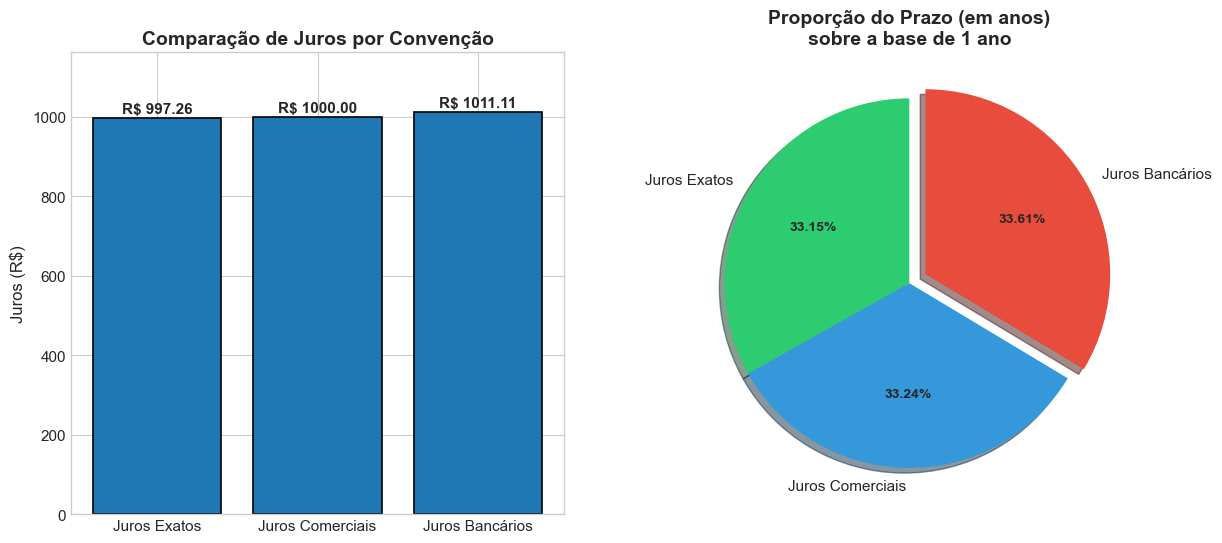

In [19]:
# grafico comparativo
fig, axes = plt.subplots(1,2, figsize=(14,6))
ax1 = axes[0]
ax2 = axes[1]

cores         = ['#2ecc71', '#3498db', '#e74c3c']
convencoes    = df_comparacao['Convenção'].tolist()
juros_valores = df_comparacao['Juros (R$)'].tolist()
prazos = df_comparacao['Prazo (anos)'].tolist()

# barras comparativas
barras = ax1.bar(convencoes,
                juros_valores,
                edgecolor='black',
                linewidth=1.2)

ax1.set_title('Comparação de Juros por Convenção', 
             fontsize=14,
             fontweight='bold')
ax1.set_ylabel('Juros (R$)', fontsize=12)
ax1.set_ylim(0, max(juros_valores) * 1.15)

for barra, valor in zip(barras, juros_valores):
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width() / 2.,
            altura+5,
            f'R$ {valor:.2f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold')

# proporcao do prazo
explode=(0, 0, 0.1)
wedges, texts, autotexts = ax2.pie(prazos,
                                  labels=convencoes,
                                  autopct='%1.2f%%',
                                  colors=cores,
                                  explode=explode,
                                  shadow=True,
                                  startangle=90)
ax2.set_title('Proporção do Prazo (em anos)\nsobre a base de 1 ano',
             fontsize=14,
             fontweight='bold')

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

### Análise para vários prazos

In [31]:
# diferentes quantidades de dias
dias_teste = [30, 60, 90, 120, 180, 270, 365]
resultados_sensibilidade = []
inicio = '2026-01-01'
capital = 10_000
taxa = 0.10

for d in dias_teste:
    data_f = datetime(2026,1,1) + timedelta(days=d)

    ex = calcular_juros_exatos(capital, taxa, inicio, data_f.strftime('%Y-%m-%d'))
    co = calcular_juros_comerciais(capital, taxa, dias_comerciais(inicio, data_f.strftime('%Y-%m-%d')))
    ba = calcular_juros_bancarios(capital, taxa, inicio, data_f.strftime('%Y-%m-%d'))

    resultados_sensibilidade.append({
        'Dias'           :d,
        'Exato (R$)'     : ex['juros'],
        'Comercial (R$)' : co['juros'],
        'Bancário (R$)'  : ba['juros']
    })

df_sens = pd.DataFrame(resultados_sensibilidade)
print()
print(df_sens.to_string(index=False))


 Dias  Exato (R$)  Comercial (R$)  Bancário (R$)
   30       82.19           83.33          83.33
   60      164.38          169.44         166.67
   90      246.58          250.00         250.00
  120      328.77          333.33         333.33
  180      493.15          497.22         500.00
  270      739.73          741.67         750.00
  365     1000.00         1000.00        1013.89


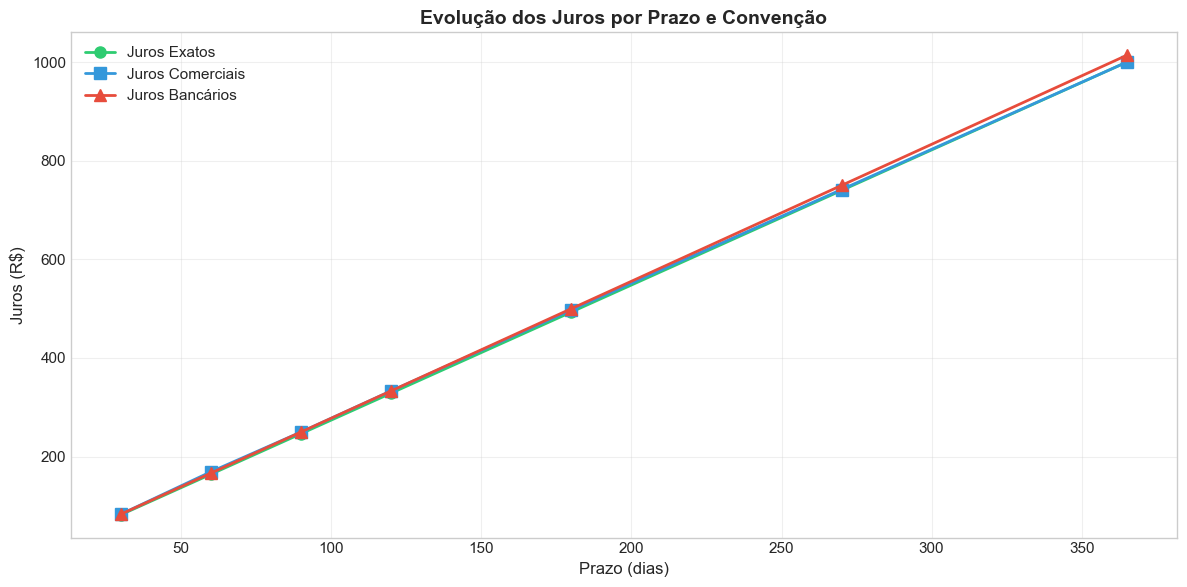

In [32]:
# grafico de linhas
plt.figure(figsize=(12,6))
plt.plot(df_sens['Dias'],
        df_sens['Exato (R$)'],
        'o-',
        color='#2ecc71',
        label='Juros Exatos',
        linewidth=2,
        markersize=8)

plt.plot(df_sens['Dias'],
        df_sens['Comercial (R$)'],
        's-',
        color='#3498db',
        label='Juros Comerciais',
        linewidth=2,
        markersize=8)

plt.plot(df_sens['Dias'], 
        df_sens['Bancário (R$)'],
        '^-',
        color='#e74c3c',
        label='Juros Bancários',
        linewidth=2,
        markersize=8)

plt.title('Evolução dos Juros por Prazo e Convenção', fontsize=14, fontweight='bold')
plt.xlabel('Prazo (dias)', fontsize=12)
plt.ylabel('Juros (R$)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()